# Task 2: Customer Segmentation Using Unsupervised Learning

**Objective:** Cluster customers based on spending habits and propose marketing strategies tailored to each segment.

**Dataset:** Mall Customers Dataset — schema-matched sample data is bundled in `data/Mall_Customers.csv`. See the README for a note on data provenance.

**Skills demonstrated:** Unsupervised learning (K-Means), dimensionality reduction (PCA, t-SNE), customer segmentation, strategy development.


## 1. Load Data & Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

df = pd.read_csv("data/Mall_Customers.csv")
print(df.shape)
df.head()

(200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Female,38,28.0,87.0
1,2,Female,23,19.1,88.8
2,3,Male,46,30.8,21.5
3,4,Male,39,57.4,47.0
4,5,Male,19,91.4,76.7


In [2]:
df.info()
print()
print(df.isna().sum())
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              200 non-null    int64  
 1   Gender                  200 non-null    str    
 2   Age                     200 non-null    int64  
 3   Annual Income (k$)      200 non-null    float64
 4   Spending Score (1-100)  200 non-null    float64
dtypes: float64(2), int64(2), str(1)
memory usage: 7.9 KB

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,34.725000,55.307500,48.398500
std,57.879185,10.258928,28.652857,29.037478
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,27.000000,25.700000,19.100000
50%,100.500000,34.000000,54.400000,49.750000
75%,150.250000,41.250000,83.850000,76.775000
max,200.000000,71.000000,107.600000,100.000000


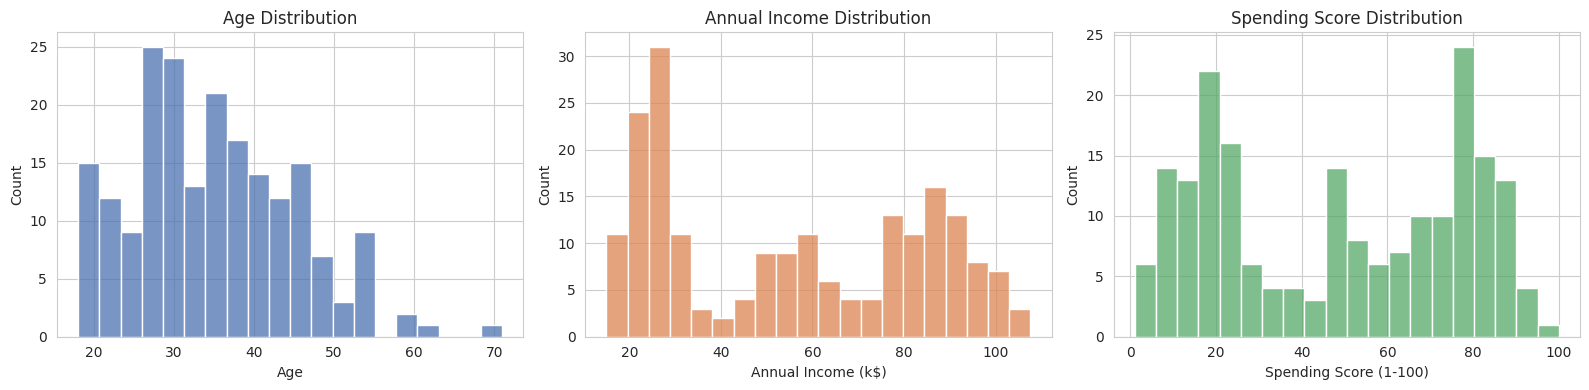

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df["Age"], bins=20, ax=axes[0], color="#4C72B0")
axes[0].set_title("Age Distribution")
sns.histplot(df["Annual Income (k$)"], bins=20, ax=axes[1], color="#DD8452")
axes[1].set_title("Annual Income Distribution")
sns.histplot(df["Spending Score (1-100)"], bins=20, ax=axes[2], color="#55A868")
axes[2].set_title("Spending Score Distribution")
plt.tight_layout()
plt.show()

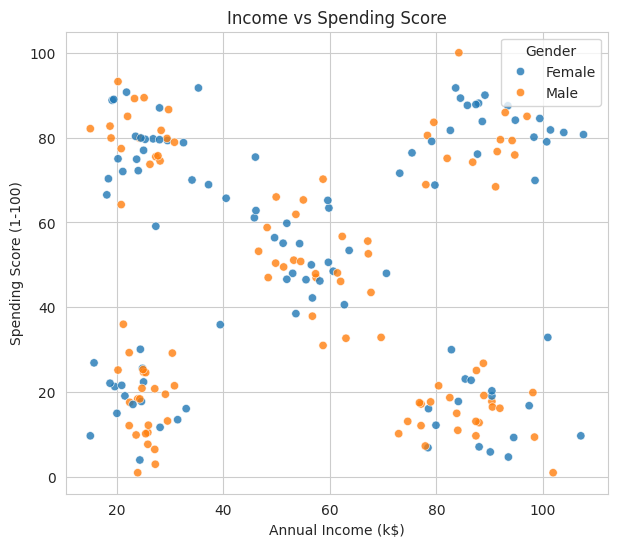

In [4]:
plt.figure(figsize=(7, 6))
sns.scatterplot(data=df, x="Annual Income (k$)", y="Spending Score (1-100)", hue="Gender", alpha=0.8)
plt.title("Income vs Spending Score")
plt.show()

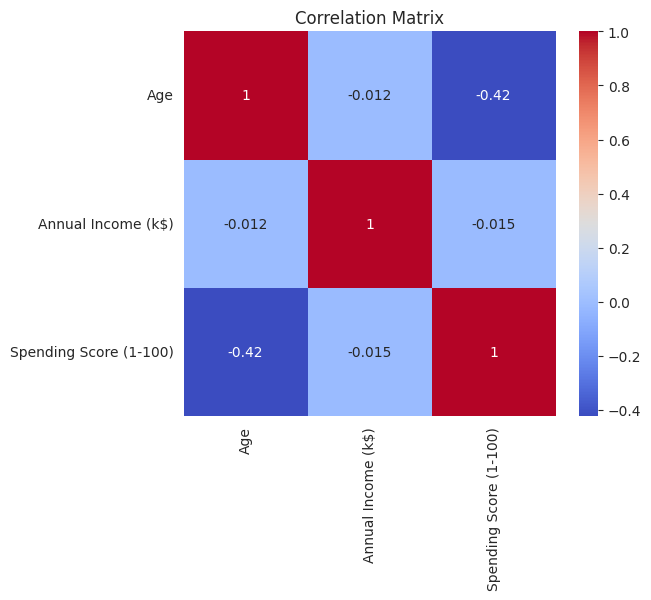

In [5]:
plt.figure(figsize=(6, 5))
sns.heatmap(df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

Income and Spending Score show almost no linear correlation — meaning customers can't be separated on either dimension alone. This confirms clustering (rather than a simple threshold rule) is the right approach.

## 2. Feature Scaling

In [6]:
features = df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)
X_scaled[:5]

array([[ 0.32003523, -0.9554379 ,  1.33270414],
       [-1.14577497, -1.26683211,  1.39484855],
       [ 1.10180066, -0.85747119, -0.9286619 ],
       [ 0.41775591,  0.07321263, -0.04828275],
       [-1.53665769,  1.26280848,  0.97710002]])

## 3. Choosing K: Elbow Method & Silhouette Score

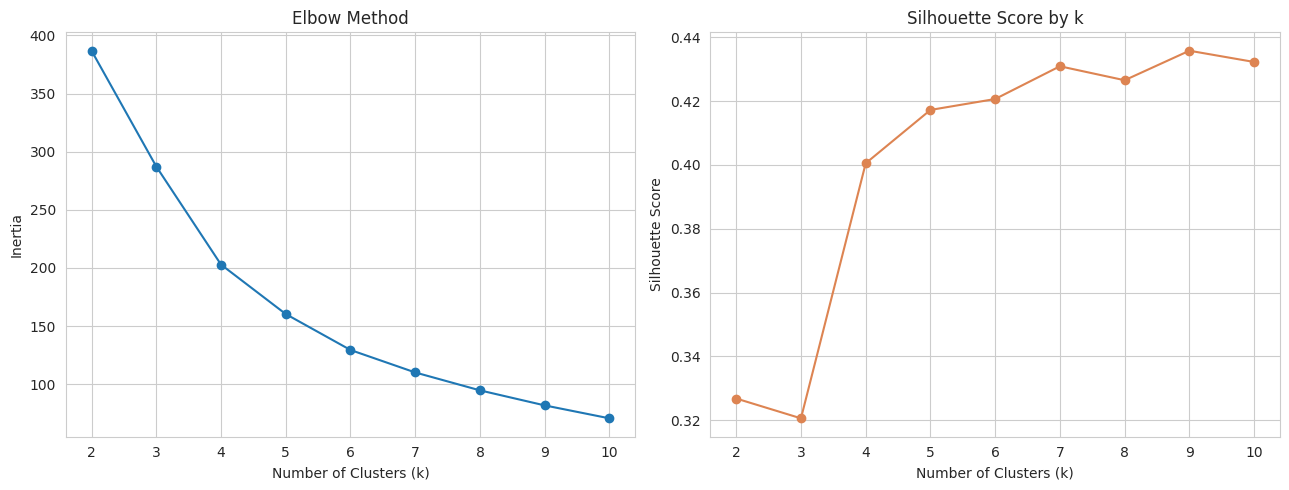

Best k by silhouette score: 9


In [7]:
inertias = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(list(K_range), inertias, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(K_range), sil_scores, marker="o", color="#DD8452")
axes[1].set_title("Silhouette Score by k")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

best_k = list(K_range)[int(np.argmax(sil_scores))]
print("Best k by silhouette score:", best_k)

## 4. Apply K-Means Clustering

In [8]:
k = 5  # Classic mall-customer segmentation typically resolves to 5 clear segments
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

print("Silhouette score at k=5:", silhouette_score(X_scaled, df["Cluster"]))
df.groupby("Cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean().round(1)

Silhouette score at k=5: 0.4172226074370709


,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,30.8,89.3,81.0
1,36.4,86.9,16.1
2,32.7,48.4,43.4
3,26.2,25.0,79.0
4,49.0,31.3,24.7


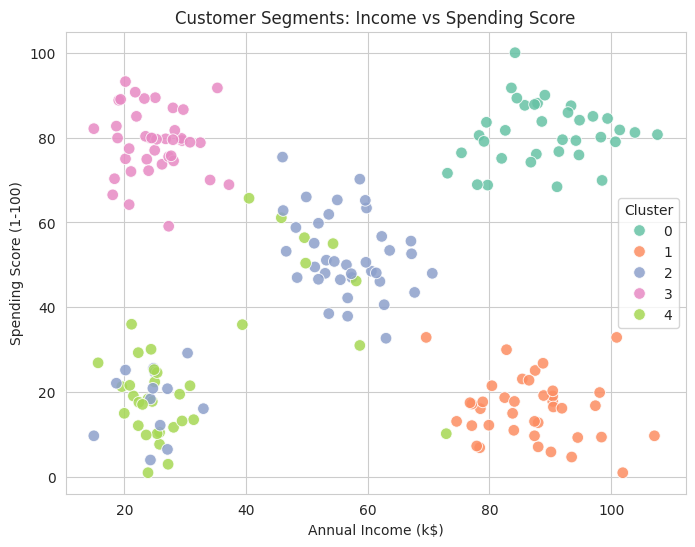

In [9]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Annual Income (k$)", y="Spending Score (1-100)",
                 hue="Cluster", palette="Set2", s=70, alpha=0.85)
plt.title("Customer Segments: Income vs Spending Score")
plt.show()

## 5. Cluster Visualization: PCA & t-SNE

Explained variance ratio: [0.47467479 0.33361019]


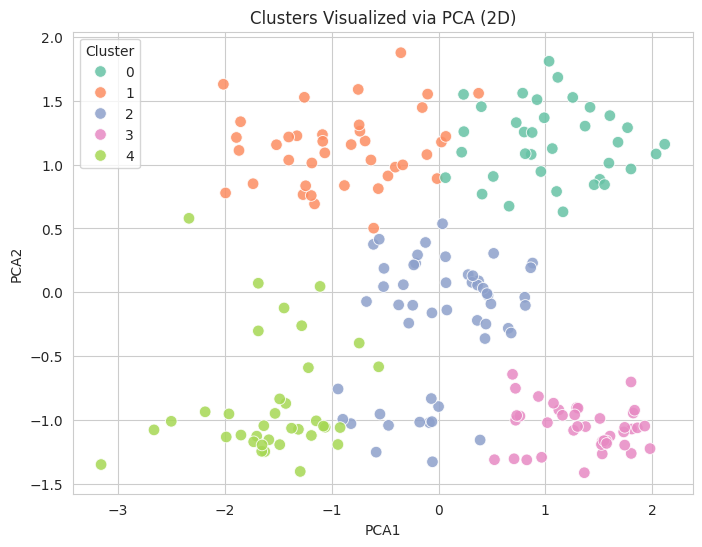

In [10]:
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_scaled)
df["PCA1"], df["PCA2"] = pca_coords[:, 0], pca_coords[:, 1]

print("Explained variance ratio:", pca.explained_variance_ratio_)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="PCA1", y="PCA2", hue="Cluster", palette="Set2", s=70, alpha=0.85)
plt.title("Clusters Visualized via PCA (2D)")
plt.show()

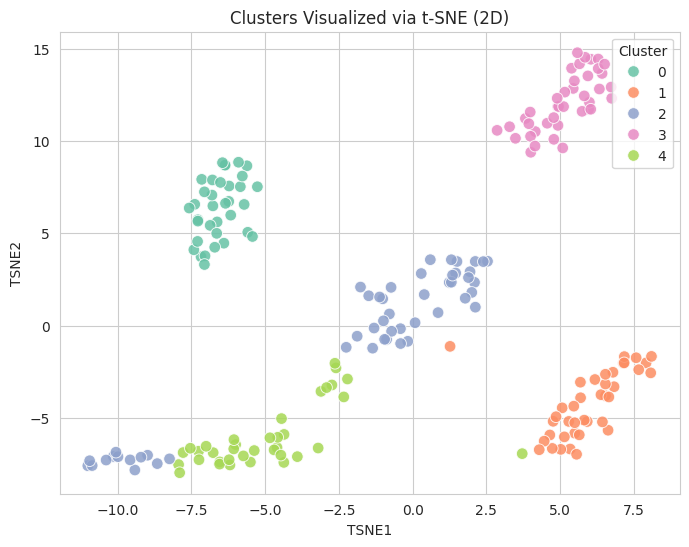

In [11]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init="pca")
tsne_coords = tsne.fit_transform(X_scaled)
df["TSNE1"], df["TSNE2"] = tsne_coords[:, 0], tsne_coords[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="TSNE1", y="TSNE2", hue="Cluster", palette="Set2", s=70, alpha=0.85)
plt.title("Clusters Visualized via t-SNE (2D)")
plt.show()

## 6. Segment Profiles & Marketing Strategy

In [12]:
profile = df.groupby("Cluster").agg(
    count=("Cluster", "size"),
    avg_age=("Age", "mean"),
    avg_income=("Annual Income (k$)", "mean"),
    avg_spending=("Spending Score (1-100)", "mean"),
).round(1)
profile

,count,avg_age,avg_income,avg_spending
Cluster,,,,
0,35,30.8,89.3,81.0
1,39,36.4,86.9,16.1
2,50,32.7,48.4,43.4
3,40,26.2,25.0,79.0
4,36,49.0,31.3,24.7


Based on the average age, income, and spending score of each cluster, we can label and target each segment:

| Cluster profile | Label | Marketing Strategy |
|---|---|---|
| Low income, low spending | **Cautious / Budget shoppers** | Value bundles, discount alerts, loyalty points to increase basket size |
| Low income, high spending | **Impulsive young spenders** | Flash sales, trendy/social-media-driven promotions, buy-now-pay-later options |
| Medium income, medium spending | **Average / Balanced customers** | Standard seasonal campaigns, cross-sell & upsell via personalized recommendations |
| High income, low spending | **Careful affluent savers** | Premium/quality-focused messaging, exclusive previews, emphasize value & durability over price |
| High income, high spending | **VIP / High-value customers** | Loyalty & VIP programs, early access, personalized concierge service, retention focus |

*(Exact cluster→label mapping should be re-checked against the `profile` table above, since KMeans cluster indices are arbitrary.)*

**General recommendation:** Marketing spend and personalization effort should scale with the "VIP" and "Impulsive young spender" segments, since they represent the highest spending-score groups, while retention campaigns for "Careful affluent savers" (high income, currently low engagement) represent the biggest untapped revenue opportunity.

## 7. Conclusion

- K-Means with **k=5** produced well-separated, business-interpretable segments, confirmed visually via both PCA and t-SNE projections.
- Segments differ meaningfully on income and spending score, with age acting as a secondary differentiator (younger high-spenders vs. older high-spenders).
- Tailored strategies per segment (above) can improve marketing ROI by matching messaging and offers to each group's behavior, instead of a one-size-fits-all campaign.
- **Next steps:** Incorporate additional behavioral features (purchase frequency, recency, category preferences) if available, and validate segment stability over time with periodic re-clustering.